In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from astropy.io import fits
from astropy.table import Table

from scipy.optimize import minimize
from scipy.optimize import least_squares


In [2]:
campo = fits.open('./M41_pm.fits')

In [3]:
campo.info()

Filename: ./M41_pm.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1                1 BinTableHDU    175   1468R x 38C   [K, D, E, D, E, D, E, E, D, E, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, L, L, E, E, 8A, D, D, D, D, D, D, J, D]   


In [4]:
campo[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional table                            
NAXIS1  =                  202 / width of table in bytes                        
NAXIS2  =                 1468 / number of rows in table                        
PCOUNT  =                    0 / heap size (no gap)                             
GCOUNT  =                    1 / one data group                                 
TFIELDS =                   38 / number of columns                              
TTYPE1  = 'source_id'          / label for column 1                             
TFORM1  = 'K       '           / format for column 1                            
TCOMM1  = 'Unique source identifier (unique within a particular Data Release)'  
TUCD1   = 'meta.id '           / VO Unified Content Descriptor for column 1     
TTYPE2  = 'ra      '        

In [5]:
Table = Table.read('./M41_pm.fits', hdu=1)

In [6]:
Table

source_id,ra,ra_error,dec,dec_error,parallax,parallax_error,pm,pmra,pmra_error,pmdec,pmdec_error,pmra_pmdec_corr,ruwe,phot_g_mean_flux_error,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_mean_flux_error,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_mean_flux_error,phot_rp_mean_flux_over_error,phot_rp_mean_mag,bp_rp,radial_velocity,has_xp_sampled,has_mcmc_msc,teff_gspphot,ag_gspphot,target_id,target_ra,target_dec,target_parallax,target_pm_ra,target_pm_dec,target_radial_velocity,epoch,target_separation (deg)
,deg,mas,deg,mas,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,'electron'.s**-1,,mag,'electron'.s**-1,,mag,'electron'.s**-1,,mag,mag,km / s,,,K,mag,,,,,,,,,
int64,float64,float32,float64,float32,float64,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool,bool,float32,float32,bytes8,float64,float64,float64,float64,float64,float64,int32,float64
2927008220678979072,101.52176143956038,0.09606511,-20.752417763726154,0.14098617,1.640919038534143,0.1709609,26.60069,5.300413680258699,0.10409646,26.067267113938783,0.16324148,0.1844313,0.9802252,0.75448906,715.6665,18.856459,8.184485,13.19941,20.254677,10.391776,61.10246,17.741024,2.5136528,--,False,False,3325.2085,0.3729,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.034802889408883306
2927009010952534400,101.4801062008522,0.086070955,-20.735265628193975,0.12844174,1.5638174876914885,0.15589298,11.571219,10.625168935995775,0.092550255,-4.582455666908314,0.14001954,0.17997208,1.0368674,0.8185382,861.2901,18.566896,7.4014378,21.252388,19.846733,6.828662,119.738045,17.466476,2.3802567,--,False,False,3538.9573,0.427,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.034898414212586715
2927008534218797184,101.53001988791614,0.012816566,-20.754326060217938,0.019032586,1.6458533025361026,0.025224358,3.4844694,-3.341235594106706,0.013646117,-0.9887724727181137,0.022531843,0.26035008,1.4604592,3309.5935,8574.298,7.054934,3709.8325,4006.4817,7.4082484,5425.532,3653.973,6.504876,0.9033723,5.5961905,True,True,--,--,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.039135202867069736
2927009530643005440,101.55286870246161,0.33389246,-20.701070627987868,0.49801323,1.5642918648963036,0.6722882,5.65642,-5.341174272690975,0.39354107,-1.86197342655909,0.61222273,0.34640393,1.0771836,0.61288154,236.71964,20.28334,3.895687,9.6487055,21.40091,5.508032,33.834408,19.072008,2.3289013,--,False,False,--,--,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.041298974748341294
2927014650244020608,101.56678960697327,0.1329185,-20.710012678267013,0.19475263,1.627882928325293,0.25267404,4.172075,-4.0700566327197665,0.147054,-0.9169770492368196,0.21317594,0.14765328,1.0260923,0.7200939,518.6538,19.2567,4.869026,16.23948,20.593506,6.246095,69.76012,18.149857,2.4436493,--,False,False,--,--,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.05113548277242355
2927012348141811072,101.4442744705353,0.3276294,-20.689806766541356,0.438405,1.667238835081918,0.6090249,2.250195,-2.228344109581384,0.3505165,-0.3128254257351102,0.6007843,0.35057065,1.0119904,0.5319839,265.7391,20.311481,5.920247,14.8365,20.479364,5.489753,19.906172,19.651545,0.8278198,--,False,False,--,--,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.07036134216063729
2927007984464857216,101.49386131221443,0.15032817,-20.78795613115958,0.24647796,1.6001315498053346,0.30282715,4.639925,-4.124106310170251,0.17047164,2.1261818311004084,0.2803015,0.24063842,3.0577784,2.789209,596.05566,17.635447,11.252494,70.83693,18.08477,11.366371,261.11658,16.066755,2.018015,--,False,True,--,--,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.07158892161678787
2927007881375881472,101.55368844353804,0.094243795,-20.781058378058344,0.14699891,1.5574637419653756,0.18014659,1.6466,-1.211962499009327,0.10261762,1.1146473021036245,0.1583806,0.24389713,1.0684234,2.2647474,318.748

In [7]:
pmra = Table['pmra']
pmdec = Table['pmdec']


ra = Table['ra']
dec = Table['dec']

g_mag = Table['phot_g_mean_mag']
bp_rp = Table['bp_rp']

### VPD

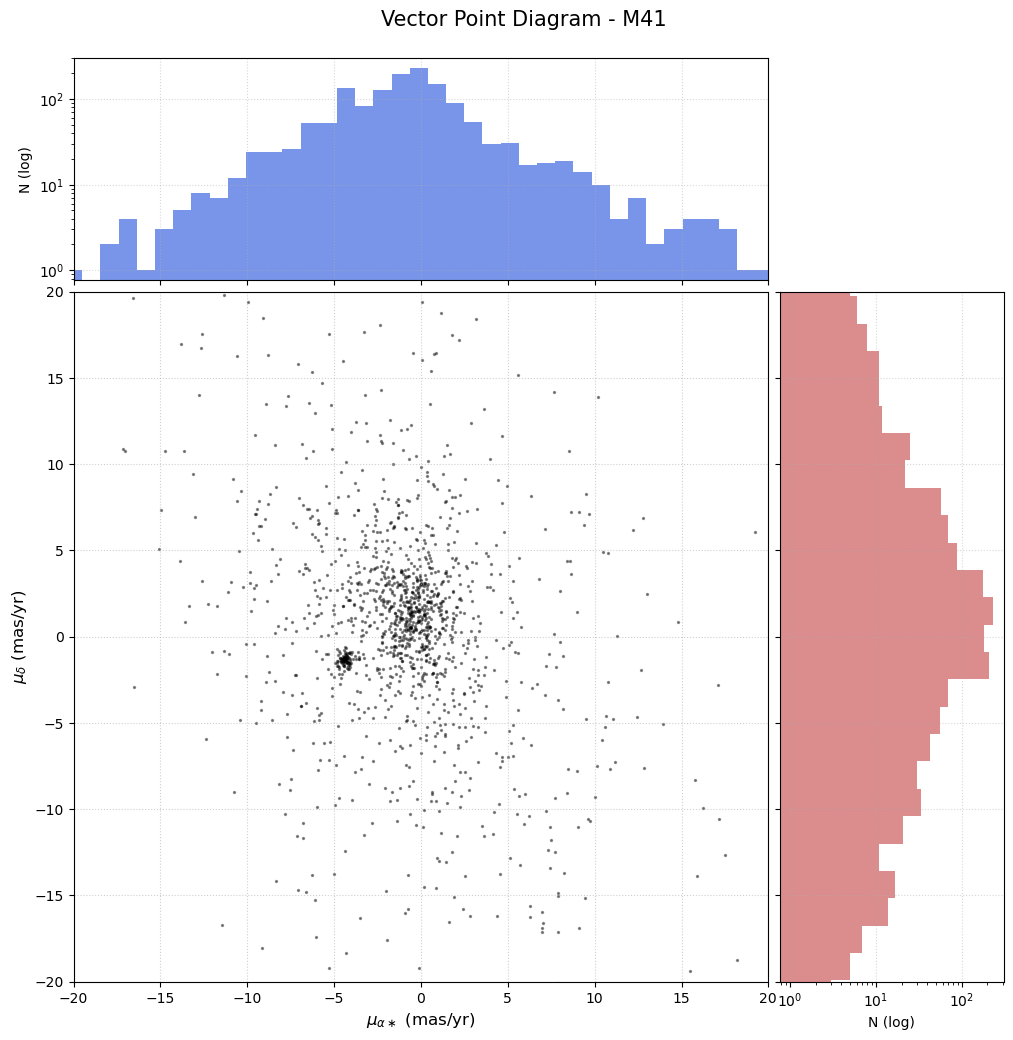

In [33]:
fig = plt.figure(figsize=(12, 12))

# Rejilla 4x4
gs = gridspec.GridSpec(4, 4, hspace=0.05, wspace=0.05)

ax_main   = fig.add_subplot(gs[1:4, 0:3])
ax_hist_x = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_hist_y = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

ax_main.scatter(pmra, pmdec, s=2, c='black', alpha=0.4)
ax_main.set_xlabel(r'$\mu_{\alpha \ast}$ (mas/yr)', fontsize=12)
ax_main.set_ylabel(r'$\mu_{\delta}$ (mas/yr)', fontsize=12)
ax_main.grid(True, linestyle=':', alpha=0.6)

ax_main.set_xlim(-20, 20)
ax_main.set_ylim(-20, 20)

ax_hist_x.hist(pmra, bins=100, color='royalblue', alpha=0.7, log=True)

ax_hist_x.set_ylabel('N (log)')
ax_hist_x.tick_params(axis='x', labelbottom=False)  # oculta etiquetas x
ax_hist_x.grid(True, linestyle=':', alpha=0.5)

ax_hist_y.hist(pmdec, bins=100, color='indianred', alpha=0.7,
               orientation='horizontal', log=True)

ax_hist_y.set_xlabel('N (log)')
ax_hist_y.tick_params(axis='y', labelleft=False)  # oculta etiquetas y
ax_hist_y.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Vector Point Diagram - M41', y=0.92, fontsize=15)
plt.show()

In [23]:
bins = 100

hist_ra, edges_ra = np.histogram(pmra, bins=bins)
hist_dec, edges_dec = np.histogram(pmdec, bins=bins)

centers_ra = 0.5 * (edges_ra[1:] + edges_ra[:-1])
centers_dec = 0.5 * (edges_dec[1:] + edges_dec[:-1])

In [27]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def residuals(params):

    mu1, sigma1, A1_ra, A2_ra, mu2, sigma2, A1_dec, A3_dec, mu3, sigma3 = params

    # Modelo RA
    model_ra = (
        gaussian(centers_ra, A1_ra, mu1, sigma1) +
        gaussian(centers_ra, A2_ra, mu2, sigma2)
    )

    # Modelo Dec
    model_dec = (
        gaussian(centers_dec, A1_dec, mu1, sigma1) +
        gaussian(centers_dec, A3_dec, mu3, sigma3)
    )

    res_ra = model_ra - hist_ra
    res_dec = model_dec - hist_dec

    return np.concatenate([res_ra, res_dec])


p0 = [
    -3, 1,          # mu1, sigma1 (cluster)
    100,          # A1_ra
    100, 0, 10,     # A2_ra, mu2, sigma2
    100,          # A1_dec
    100, 0, 8     # A3_dec, mu3, sigma3
]

In [ ]:
result = least_squares(residuals, p0)
params_fit = result.x

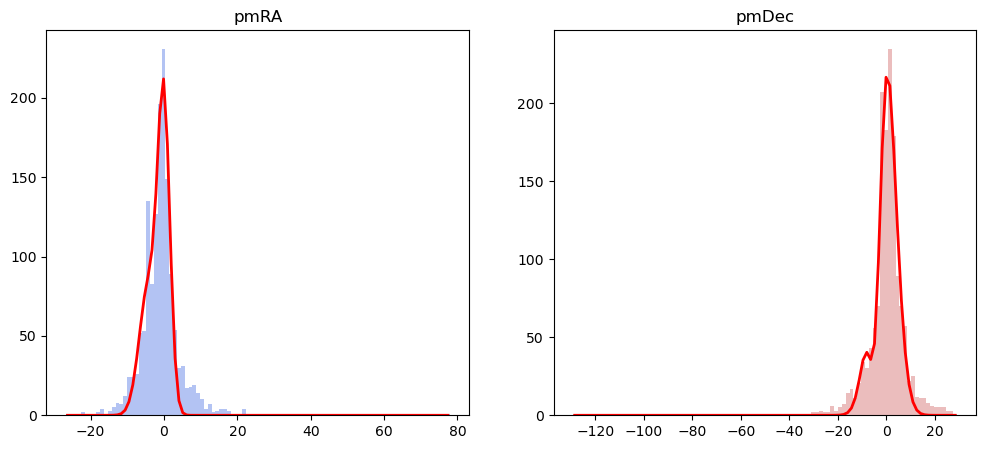

In [31]:
mu1, sigma1, A1_ra, A2_ra, mu2, sigma2, A1_dec, A3_dec, mu3, sigma3 = params_fit

model_ra = (
    gaussian(centers_ra, A1_ra, mu1, sigma1) +
    gaussian(centers_ra, A2_ra, mu2, sigma2)
)

model_dec = (
    gaussian(centers_dec, A1_dec, mu1, sigma1) +
    gaussian(centers_dec, A3_dec, mu3, sigma3)
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(centers_ra, hist_ra, width=np.diff(edges_ra)[0], alpha=0.4, color='royalblue')
plt.plot(centers_ra, model_ra, 'r-', lw=2)
plt.title("pmRA")

plt.subplot(1,2,2)
plt.bar(centers_dec, hist_dec, width=np.diff(edges_dec)[0], alpha=0.4, color='indianred')
plt.plot(centers_dec, model_dec, 'r-', lw=2)
plt.title("pmDec")

plt.show()

In [32]:
# Extraer parámetros ajustados
mu1, sigma1, A1_ra, A2_ra, mu2, sigma2, A1_dec, A3_dec, mu3, sigma3 = params_fit

print("\n===== Parámetros Ajustados =====\n")

print("Gaussiana 1 (Cluster - compartida RA y Dec)")
print(f"  μ1  = {mu1:.4f} mas/yr")
print(f"  σ1  = {sigma1:.4f} mas/yr\n")

print("Gaussiana 2 (Campo en pmRA)")
print(f"  μ2  = {mu2:.4f} mas/yr")
print(f"  σ2  = {sigma2:.4f} mas/yr\n")

print("Gaussiana 3 (Campo en pmDec)")
print(f"  μ3  = {mu3:.4f} mas/yr")
print(f"  σ3  = {sigma3:.4f} mas/yr\n")


===== Parámetros Ajustados =====

Gaussiana 1 (Cluster - compartida RA y Dec)
  μ1  = -4.2520 mas/yr
  σ1  = 2.5036 mas/yr

Gaussiana 2 (Campo en pmRA)
  μ2  = -0.0476 mas/yr
  σ2  = 1.6593 mas/yr

Gaussiana 3 (Campo en pmDec)
  μ3  = -1.1686 mas/yr
  σ3  = 4.6558 mas/yr



### Probabilidades de pertenencia

In [41]:
# Definición de las funciones de densidad (PDF)
def psi_cluster(mu_x, mu_y, mux_c, muy_c, sigma_c):
    """PDF circular para el cúmulo """
    return (1.0 / (2 * np.pi * sigma_c**2)) * np.exp(-0.5 * ((mu_x - mux_c)**2 + (mu_y - muy_c)**2) / sigma_c**2)

def psi_field(mu_x, mu_y, mux_f, muy_f, sigx_f, sigy_f, rho):
    """PDF elíptica para el campo """
    z = ((mu_x - mux_f)**2 / sigx_f**2 + 
         (mu_y - muy_f)**2 / sigy_f**2 - 
         2 * rho * (mu_x - mux_f) * (mu_y - muy_f) / (sigx_f * sigy_f))
    norm = 1.0 / (2 * np.pi * sigx_f * sigy_f * np.sqrt(1 - rho**2))
    return norm * np.exp(-0.5 * z / (1 - rho**2))

# Función de Verosimilitud (Log-Likelihood)
def neg_log_likelihood(params, mu_x, mu_y):
    """Calcula el logaritmo negativo de la verosimilitud total """
    mux_c, muy_c, sigma_c, mux_f, muy_f, sigx_f, sigy_f, rho, nf = params
    
    # Restricciones lógicas
    if sigma_c <= 0 or sigx_f <= 0 or sigy_f <= 0 or not (-1 < rho < 1) or not (0 <= nf <= 1):
        return 1e15
    
    pc = psi_cluster(mu_x, mu_y, mux_c, muy_c, sigma_c)
    pf = psi_field(mu_x, mu_y, mux_f, muy_f, sigx_f, sigy_f, rho)
    
    total_psi = (1 - nf) * pc + nf * pf
    # Evitar log(0)
    return -np.sum(np.log(total_psi + 1e-10))

def calculate_membership(pmra, pmdec):
    # Estimación inicial (Crucial para la convergencia)
    # Para M41: mux ~ -4.5, muy ~ -1.8 mas/yr
    initial_guess = [
        -4.3665, -1.3399 , 0.2633,     # Cluster: mux, muy, sigma
        -0.7410, -0.6275, 5.1546, 7.3140,  # Field: mux, muy, sigx, sigy
        0.0,                 # rho
        0.9                  # nf 
    ]

#def calculate_membership(pmra, pmdec):
#    # Estimación inicial (Crucial para la convergencia)
    # Para M41: mux ~ -4.5, muy ~ -1.8 mas/yr
#    initial_guess = [
#        -4.2520, -4.2520 , 2.5036,     # Cluster: mux, muy, sigma
#        -0.0476, -1.1686, 1.6593, 4.6558,  # Field: mux, muy, sigx, sigy
#        0.0,                 # rho
#        0.9                  # nf 
#    ]
    
    # Minimización usando SciPy
    res = minimize(neg_log_likelihood, initial_guess, args=(pmra, pmdec), method='L-BFGS-B',
                   bounds=[(None, None), (None, None), (0.01, None), 
                           (None, None), (None, None), (0.1, None), (0.1, None), 
                           (-0.99, 0.99), (0, 1)])
    
    if not res.success:
        print("Error en la optimización:", res.message)
        return None

    # Parámetros optimizados
    p = res.x
    #print("Parámetros finales:", p)

    # Cálculo de Probabilidades de Pertenencia (Regla de Bayes)
    # P = (Prob_Cúmulo) / (Prob_Total) [cite: 591, 594]
    pc_final = (1 - p[8]) * psi_cluster(pmra, pmdec, p[0], p[1], p[2])
    pf_final = p[8] * psi_field(pmra, pmdec, p[3], p[4], p[5], p[6], p[7])
    
    probabilities = pc_final / (pc_final + pf_final)
    
    return probabilities, p

In [42]:
probabilities, p = calculate_membership(pmra, pmdec)

names = [
    "µ_xc (Cluster RA)", "µ_yc (Cluster Dec)", "σ_c (Cluster Dispersion)",
    "µ_xf (Field RA)", "µ_yf (Field Dec)", "σx_f (Field RA Disp)",
    "σy_f (Field Dec Disp)", "ρ (Correlation)", "n_f (Field Fraction)"
]
print("-" * 45)
print(f"{'Parámetro':<25} | {'Valor':<15}")
print("-" * 45)
for name, value in zip(names, p):
    print(f"{name:<25} | {value:>15.4f}")
print("-" * 45)

---------------------------------------------
Parámetro                 | Valor          
---------------------------------------------
µ_xc (Cluster RA)         |         -4.3668
µ_yc (Cluster Dec)        |         -1.3399
σ_c (Cluster Dispersion)  |          0.2634
µ_xf (Field RA)           |         -0.7413
µ_yf (Field Dec)          |          0.6276
σx_f (Field RA Disp)      |          5.1545
σy_f (Field Dec Disp)     |          7.3152
ρ (Correlation)           |         -0.2816
n_f (Field Fraction)      |          0.9455
---------------------------------------------


---------------------------------------------
RESULTADO DEL FILTRADO (P > 0.5)
---------------------------------------------
Estrellas totales:      1468
Miembros encontrados:   85
Porcentaje de éxito:    5.79%
---------------------------------------------


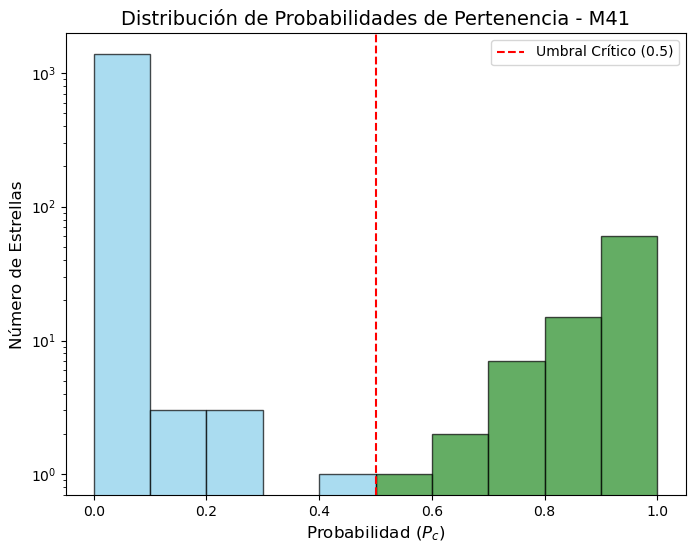

In [43]:
umbral = 0.5

# Conteo de miembros con P > umbral
n_members = np.sum(probabilities > umbral)
total_stars = len(probabilities)
percentage = (n_members / total_stars) * 100

print("-" * 45)
print(f"RESULTADO DEL FILTRADO (P > {umbral})")
print("-" * 45)
print(f"Estrellas totales:      {total_stars}")
print(f"Miembros encontrados:   {n_members}")
print(f"Porcentaje de éxito:    {percentage:.2f}%")
print("-" * 45)

# Histograma
plt.figure(figsize=(8, 6))

counts, bins, patches = plt.hist(probabilities, bins=10, range=(0, 1), color='skyblue', edgecolor='black', alpha=0.7)

# Resaltamos la zona de miembros en un color distinto
for i in range(len(patches)):
    if bins[i] >= umbral:
        patches[i].set_facecolor('forestgreen')

plt.axvline(umbral, color='red', linestyle='--', label=f'Umbral Crítico ({umbral})')

plt.title('Distribución de Probabilidades de Pertenencia - M41', fontsize=14)
plt.xlabel('Probabilidad ($P_c$)', fontsize=12)
plt.ylabel('Número de Estrellas', fontsize=12)
plt.yscale('log')  # Escala logarítmica para ver mejor el pico del cúmulo si es pequeño
plt.legend()

plt.show()

### Visualizacion del Cumulo

In [44]:
# Crear la máscara (Probabilidad > umbral)
mask = probabilities > umbral
mas_bot = probabilities < umbral

# Aplicar la máscara a todos los datos
m_ra, m_dec = ra[mask], dec[mask]
m_pmra, m_pmdec = pmra[mask], pmdec[mask]
m_g, m_bprp = g_mag[mask], bp_rp[mask]

m_g_bot, m_bprp_bot = g_mag[mas_bot], bp_rp[mas_bot]

print(f"Estrellas identificadas como miembros probables: {len(m_ra)}")

Estrellas identificadas como miembros probables: 85


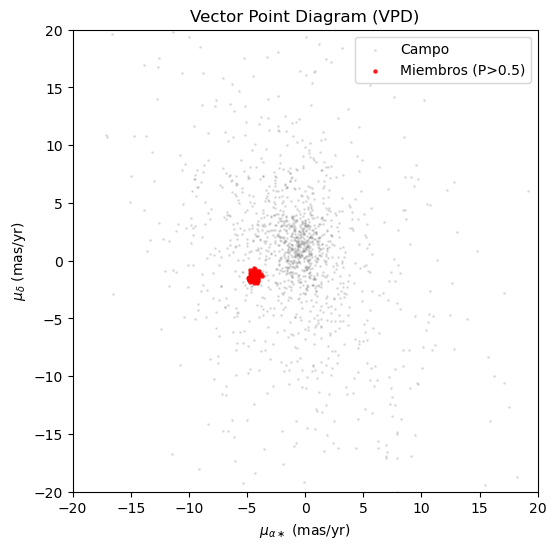

In [45]:
plt.figure(figsize=(6,6))

plt.scatter(pmra, pmdec, c='gray', s=1, alpha=0.2, label='Campo')
plt.scatter(m_pmra, m_pmdec, c='red', s=5, alpha=0.8, label=f'Miembros (P>{umbral})')

plt.xlabel(r'$\mu_{\alpha \ast}$ (mas/yr)')
plt.ylabel(r'$\mu_{\delta}$ (mas/yr)')
plt.title('Vector Point Diagram (VPD)')
plt.legend()

plt.xlim(-20, 20)  
plt.ylim(-20, 20)

plt.show()

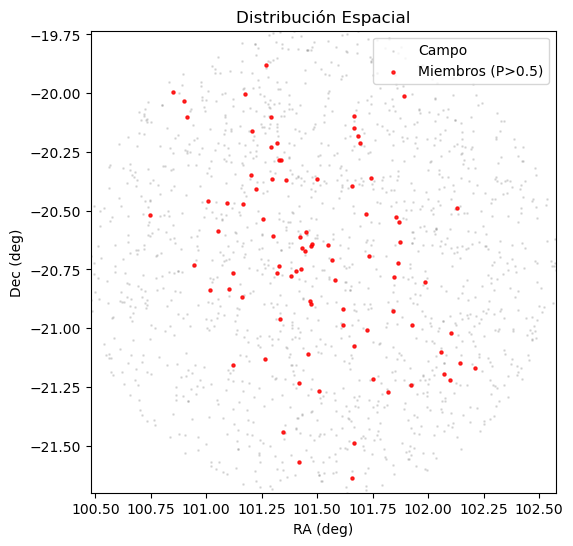

In [46]:
plt.figure(figsize=(6,6))

plt.scatter(ra, dec, c='gray', s=1, alpha=0.2, label='Campo')
plt.scatter(m_ra, m_dec, c='red', s=5, alpha=0.8, label=f'Miembros (P>{umbral})')

plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title('Distribución Espacial')
plt.legend()

plt.xlim(min(ra), max(ra)) 
plt.ylim(min(dec), max(dec))

plt.show()

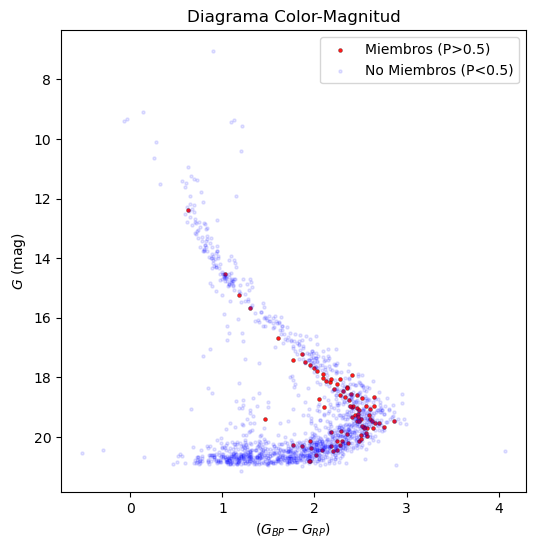

In [47]:
plt.figure(figsize=(6,6))

#plt.scatter(bp_rp, g_mag, c='gray', s=1, alpha=0.2, label='Campo')
plt.scatter(m_bprp, m_g, c='red', s=8, alpha=0.9, edgecolors='black', linewidths=0.2, label=f'Miembros (P>{umbral})')
plt.scatter(m_bprp_bot, m_g_bot, c='blue', s=5, alpha=0.1, label=f'No Miembros (P<{umbral})')

plt.xlabel('$(G_{BP} - G_{RP})$')
plt.ylabel('$G$ (mag)')
plt.gca().invert_yaxis()
plt.title('Diagrama Color-Magnitud')
plt.legend()    

plt.show()